In [1]:
# 데이터 확인하기 2025.11.20 154개 컬럼을 사용해 기본 모델 돌리기
import pandas as pd
import numpy  as np

from sklearn.preprocessing import StandardScaler # 데이터 전처리용

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 데이터 로딩
data_path_train = '../data/train.csv'
data_path_test  = '../data/test.csv'

train = pd.read_csv(data_path_train)
test  = pd.read_csv(data_path_test)

In [ ]:
# Data 전처리 1. zero_count_rate이 99%인 컬럼 제거하기 
remove_cols = pd.read_csv('../doc/remove_cols.csv', header=0).squeeze()
train.drop(columns=remove_cols, axis=1, inplace=True)
test.drop(columns=remove_cols, axis=1, inplace=True)

In [5]:
# 데이터 할당
X_features = train.drop(columns=['ID', 'TARGET'], axis=1) # ID와 TARGET 모두 제거하고 X_train 만들기
y_labels   = train['TARGET']
X_test     = test.drop(columns=['ID'], axis=1) # test 데이터에서도 ID 제거 
X_features.columns # 152개

Index(['var3', 'var15', 'imp_ent_var16_ult1', 'imp_op_var39_comer_ult1',
       'imp_op_var39_comer_ult3', 'imp_op_var41_comer_ult1',
       'imp_op_var41_comer_ult3', 'imp_op_var41_efect_ult1',
       'imp_op_var41_efect_ult3', 'imp_op_var41_ult1',
       ...
       'saldo_medio_var8_ult3', 'saldo_medio_var12_hace2',
       'saldo_medio_var12_hace3', 'saldo_medio_var12_ult1',
       'saldo_medio_var12_ult3', 'saldo_medio_var13_corto_hace2',
       'saldo_medio_var13_corto_hace3', 'saldo_medio_var13_corto_ult1',
       'saldo_medio_var13_corto_ult3', 'var38'],
      dtype='object', length=152)

In [6]:
# Data 전처리 2. var3 의 최소값 -99999 를 최빈값으로 변경하기
X_features['var3'] = X_features['var3'].replace(-999999, 2)

In [ ]:
# 152개 컬럼의 데이터 전처리한 것 저장해 두기, 다음에 다시 테스트할때 대비
# X_features.to_csv('../data/x_train_152cols.csv')
# X_test.to_csv('../data/x_test_152cols.csv')

In [8]:
# 스케일링
# X_train_scaled, X_test_scaled, scaler = scale_data(X_train=X, X_test=X_test)
scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X_features)
X_test_scaled = scaler.transform(X_test)


In [9]:
# 레이블의 분포 확인
cust_cnt = y_labels.value_counts()
print(cust_cnt) # 1이 불만족 3008명, 만족이 73012

# 불만족고객의 비율
cust_rate = cust_cnt[1] / cust_cnt.sum()
print(f'불만족 고객 비율: {cust_rate:.2f}')

TARGET
0    73012
1     3008
Name: count, dtype: int64
불만족 고객 비율: 0.04


In [25]:
type(X_scaled)

numpy.ndarray

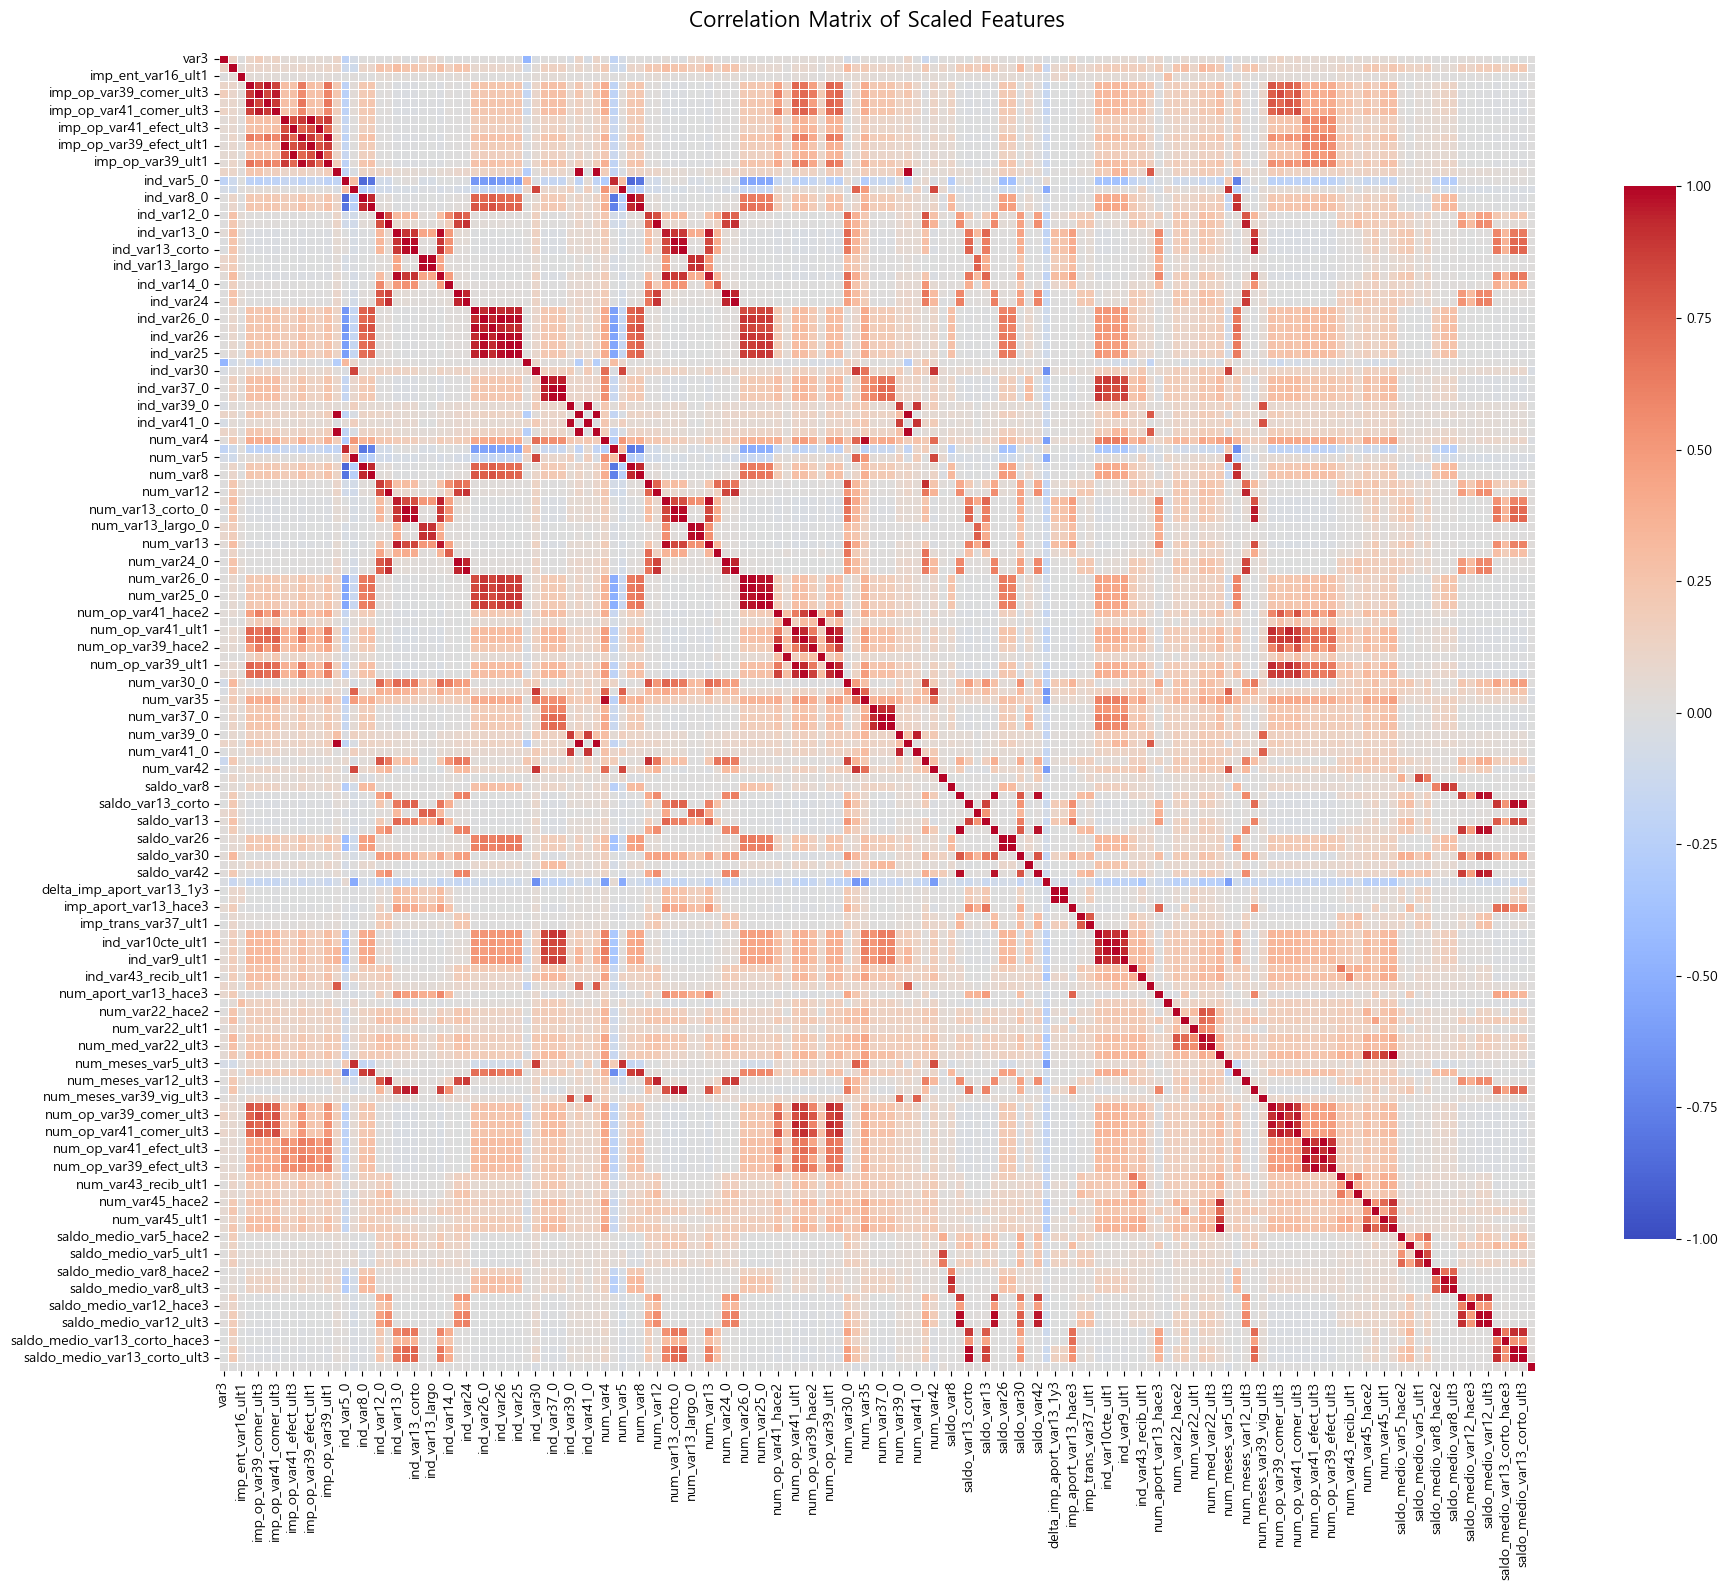

상관관계 통계 요약
평균 상관계수: 0.1220
최대 상관계수: 1.0000
최소 상관계수: -0.8659
표준편차: 0.2061

높은 상관관계 변수 쌍 (|correlation| > 0.7)
                   Variable 1                    Variable 2  Correlation
    delta_imp_aport_var13_1y3     delta_num_aport_var13_1y3     1.000000
                  ind_var25_0                     ind_var25     1.000000
                  ind_var37_0                     ind_var37     1.000000
                  num_var37_0                     num_var37     1.000000
                  num_var26_0                     num_var26     1.000000
                  ind_var26_0                     ind_var26     1.000000
                  num_var25_0                     num_var25     1.000000
                     ind_var8                      num_var8     1.000000
                   ind_var8_0                    num_var8_0     0.999793
              ind_var13_corto               num_var13_corto     0.999670
                    ind_var24                     num_var24     0.999461
               

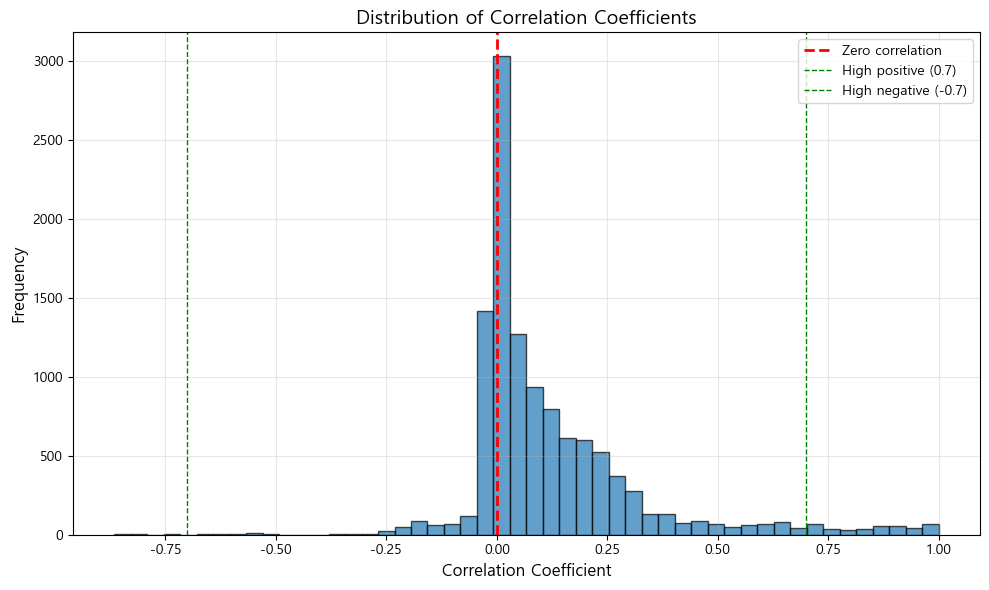

In [ ]:
# 상관관계 시각화 시도
# 1. numpy array를 DataFrame으로 변환 (컬럼명 복원)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_features.columns)

# 2. 상관관계 행렬 계산
correlation_matrix = X_scaled_df.corr()

# 3. 상관관계 히트맵 시각화
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=False,  # 숫자 표시 (변수가 많으면 False)
            cmap='coolwarm',  # 색상 테마
            center=0,  # 0을 중심으로
            vmin=-1, vmax=1,  # 범위 -1 ~ 1
            square=True,  # 정사각형 셀
            linewidths=0.5,  # 셀 구분선
            cbar_kws={"shrink": 0.8})  # 컬러바 크기

plt.title('Correlation Matrix of Scaled Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# 4. 상관관계 통계 요약
print("=" * 60)
print("상관관계 통계 요약")
print("=" * 60)

# 대각선(자기 자신과의 상관관계) 제외
corr_values = correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)]
print(f"평균 상관계수: {corr_values.mean():.4f}")
print(f"최대 상관계수: {corr_values.max():.4f}")
print(f"최소 상관계수: {corr_values.min():.4f}")
print(f"표준편차: {corr_values.std():.4f}")

# 5. 높은 상관관계 쌍 찾기 (절댓값 기준)
print("\n" + "=" * 60)
print("높은 상관관계 변수 쌍 (|correlation| > 0.7)")
print("=" * 60)

# 상위 삼각 행렬만 추출 (중복 제거)
upper_tri = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# 높은 상관관계 찾기
high_corr = []
for column in upper_tri.columns:
    for index in upper_tri.index:
        corr_val = upper_tri.loc[index, column]
        if pd.notna(corr_val) and abs(corr_val) > 0.7:
            high_corr.append({
                'Variable 1': index,
                'Variable 2': column,
                'Correlation': corr_val
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', 
                                                     key=abs, 
                                                     ascending=False)
print(high_corr_df.to_string(index=False))
print(f"\n총 {len(high_corr_df)}개의 높은 상관관계 쌍 발견")

# 6. 특정 변수와의 상관관계 (예: 'var15'와의 상관관계)
if 'var15' in X_scaled_df.columns:
    print("\n" + "=" * 60)
    print("'var15'와 상관관계가 높은 변수들 (상위 10개)")
    print("=" * 60)
    var15_corr = correlation_matrix['var15'].abs().sort_values(ascending=False)
    print(var15_corr.head(11)[1:])  # 자기 자신 제외

# 7. 상관관계 분포 히스토그램
plt.figure(figsize=(10, 6))
plt.hist(corr_values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Correlation Coefficients', fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero correlation')
plt.axvline(x=0.7, color='green', linestyle='--', linewidth=1, label='High positive (0.7)')
plt.axvline(x=-0.7, color='green', linestyle='--', linewidth=1, label='High negative (-0.7)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 2000x1600 with 0 Axes>

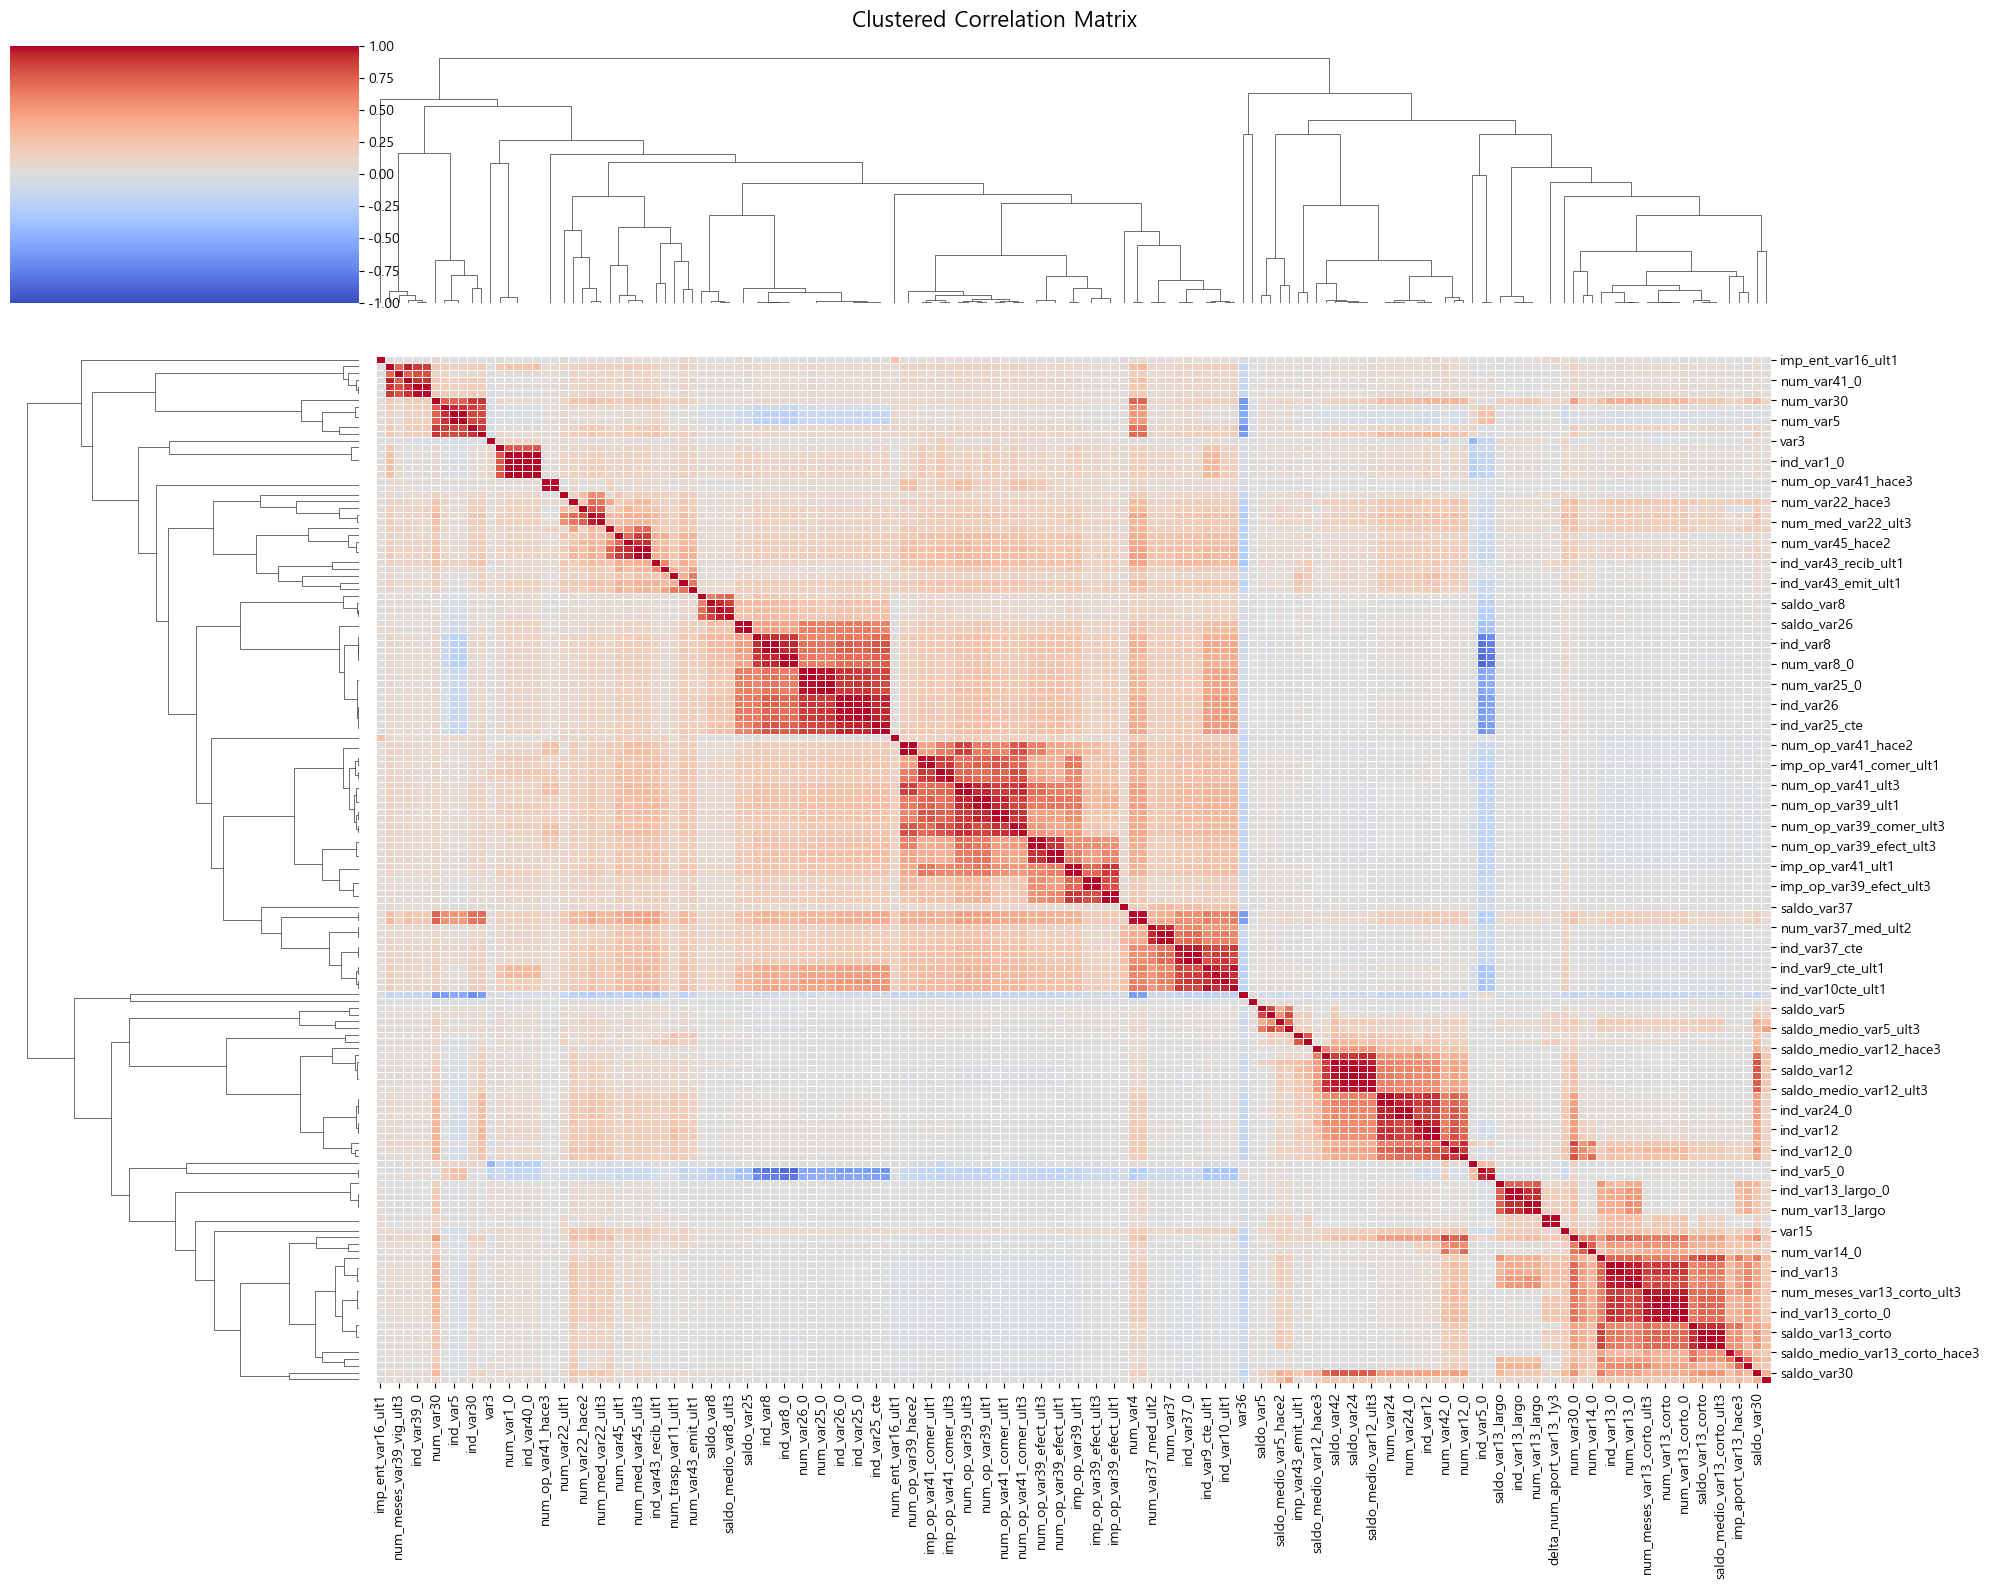

In [30]:
# seaborn이 자동으로 클러스터링 처리
plt.figure(figsize=(20, 16))

g = sns.clustermap(correlation_matrix,
                   cmap='coolwarm',
                   center=0,
                   vmin=-1, vmax=1,
                   method='average',  # 클러스터링 방법
                   metric='correlation',  # 거리 측정 방법
                   figsize=(20, 16),
                   linewidths=0.5,
                   cbar_kws={"shrink": 0.8})

g.fig.suptitle('Clustered Correlation Matrix', fontsize=16, y=0.99)
plt.tight_layout()
plt.show()

In [ ]:
# 상위 20개 변수만 선택
n_top = 20
top_vars = X_scaled_df.columns[:n_top]
top_corr = correlation_matrix.loc[top_vars, top_vars]

plt.figure(figsize=(12, 10))
sns.heatmap(top_corr, 
            annot=True,  # 숫자 표시
            fmt='.2f',  # 소수점 2자리
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)

plt.title(f'Correlation Matrix (Top {n_top} Variables)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

C:\Users\july1\AppData\Local\Temp\ipykernel_13120\2240095329.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


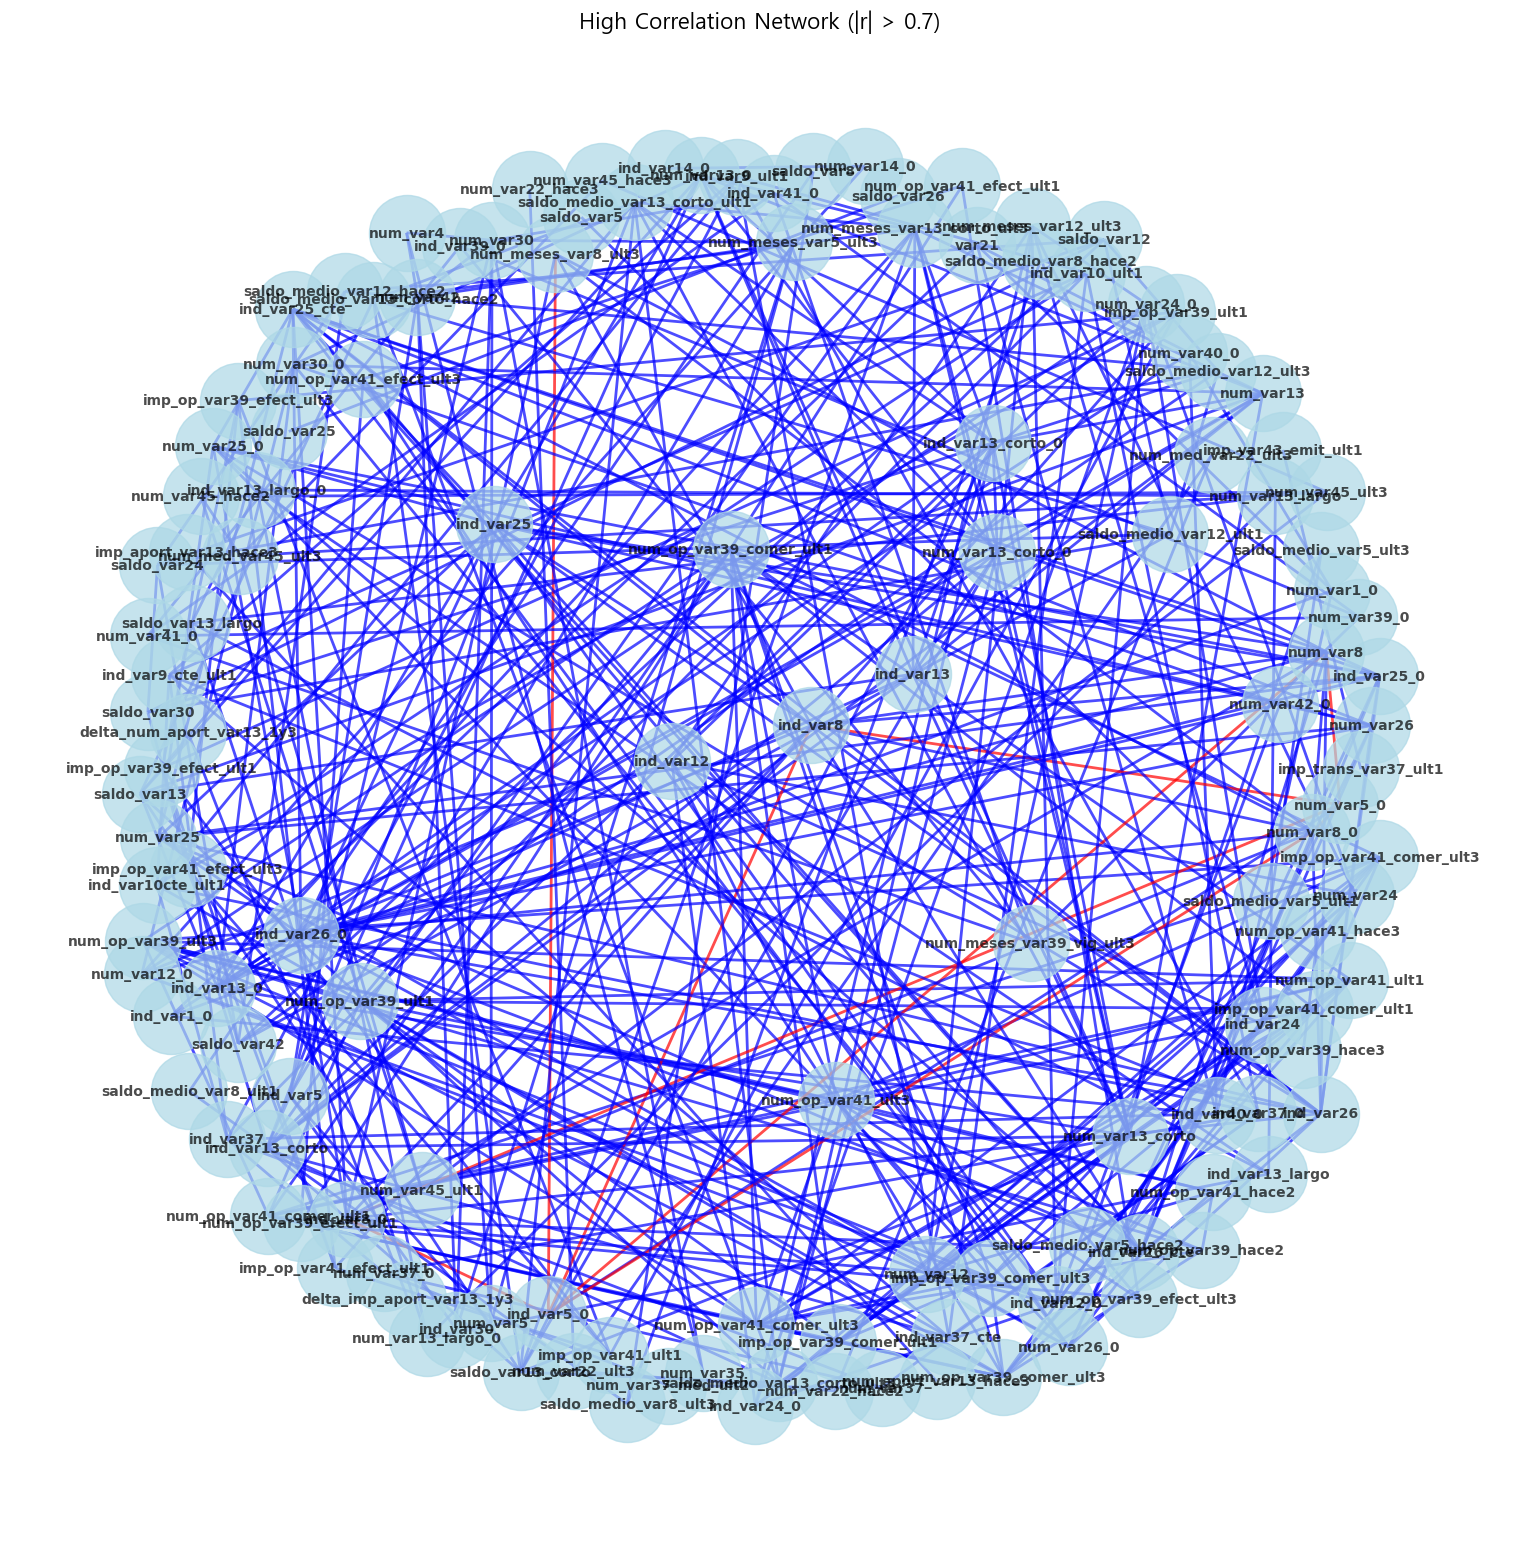

In [29]:
import networkx as nx

# 높은 상관관계만 네트워크로 표현
threshold = 0.7
G = nx.Graph()

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            G.add_edge(
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                weight=correlation_matrix.iloc[i, j]
            )

if len(G.edges()) > 0:
    plt.figure(figsize=(15, 15))
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # 엣지 색상 (양/음의 상관관계)
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    colors = ['red' if w < 0 else 'blue' for w in weights]
    
    nx.draw(G, pos,
            with_labels=True,
            node_color='lightblue',
            node_size=3000,
            font_size=10,
            font_weight='bold',
            edge_color=colors,
            width=2,
            alpha=0.7)
    
    plt.title(f'High Correlation Network (|r| > {threshold})', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print(f"상관관계가 {threshold} 이상인 변수 쌍이 없습니다.")

In [ ]:
# first testing model
# XGBoost (xgb) : yjh, kjh
# LightGBM(lgbm) : lsj, ujm
# Random Forest(rf) : lkj, kjh
# Logistic Regression(lr) : yjh, ujm


In [10]:
# 학습/테스트 데이터 분리
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
  X_features, 
  y_labels,
  test_size    = 0.2, 
  random_state = 23, # 세미프로젝트3조
  stratify = y_labels
)


In [ ]:
# from sklearn.metrics import confusion_matrix, accuracy_score
# from sklearn.metrics import precision_score, recall_score
# from sklearn.metrics import f1_score, roc_auc_score 
# from sklearn.model_selection import train_test_split

# def get_clf_eval(y_test, pred, pred_proba):
#     confusion = confusion_matrix(y_test, pred) 
#     accuracy  = accuracy_score(y_test, pred)
#     precision = precision_score(y_test, pred)
#     recall    = recall_score(y_test, pred)
#     f1        = f1_score(y_test, pred)
#     # AUC
#     roc_auc   = roc_auc_score(y_test, pred_proba)
#     # print('오차행렬: ')
#     # print(confusion)
#     print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}')
from utils.utils import get_clf_eval

ModuleNotFoundError: No module named 'utils'

In [ ]:
# Model 학습, 평가
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics  import roc_auc_score, accuracy_score, classification_report, confusion_matrix

# 기본값으로 우선 RF 해 보자
rf_clf = RandomForestClassifier(
  random_state = 0,
  n_estimators = 100,
  max_depth    = 8, # RF : 애가 핵심이야 Tree 계열이니까~ 약한 Tree로 만들어야해 그래서 max_depth로 자른거
  n_jobs       = -1 # 병렬처리 여부 
)
rf_clf.fit(X_train, y_train)    # 학습
pred       = rf_clf.predict(X_val)   # 예측
pred_proba = rf_clf.predict_proba(X_val)[:,1] # 예측확률

get_clf_eval(y_test=y_val, pred=pred, pred_proba=pred_proba)

오차행렬: 
[[14601     1]
 [  601     1]]
정확도: 0.9604, 정밀도: 0.5000, 재현율: 0.0017, F1: 0.0033, AUC: 0.8173


In [58]:
X_train.shape

(60816, 152)